<a href="https://colab.research.google.com/github/chrishan-92/ComputerVisionAssignment01/blob/Master/Comp_VIsion_Assigment_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipython-input-3143018987.py:85: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(out, mode="L").save(output_path)


✅ Saved: /content/drive/MyDrive/Computer Vision/Assignment 1/emma_transformed.jpg


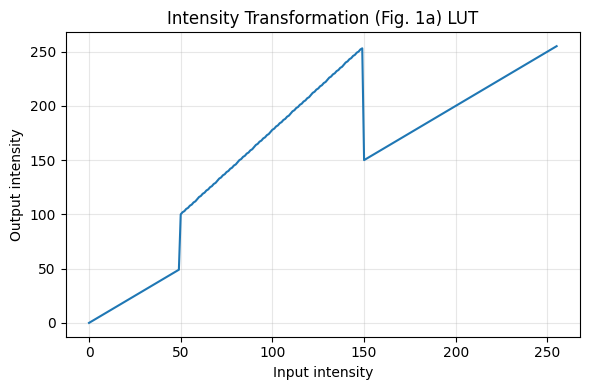

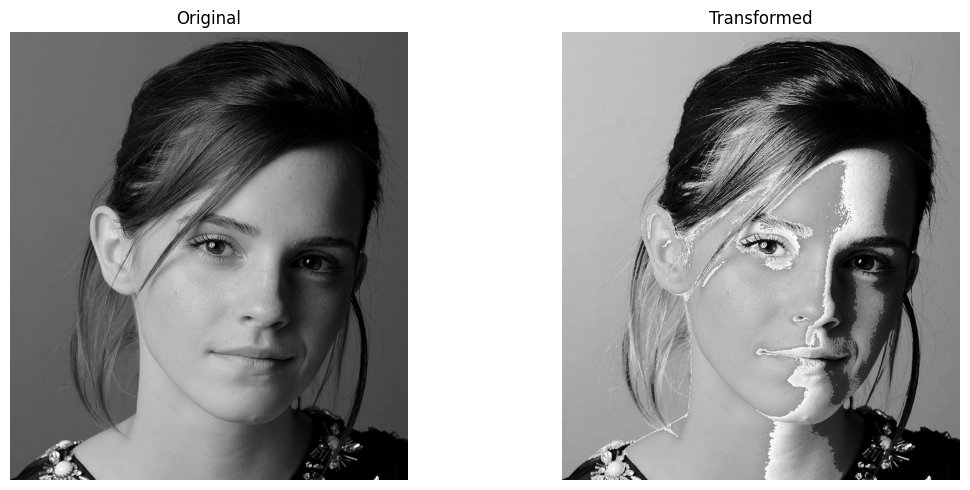

In [5]:
"""
Intensity transform (Fig. 1a) with a lookup table (LUT).

- Reads a grayscale image
- Applies the piecewise intensity mapping via LUT
- Saves the transformed image
- Optionally plots the LUT and before/after images

Author: Basti (intermediate style)
"""

from __future__ import annotations
from pathlib import Path
from typing import Tuple, Optional

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt


# ------------------------- LUT (Fig. 1a) ------------------------- #
def build_fig1a_lut() -> np.ndarray:
    """
    Build a 256-length LUT for the Fig. 1a transform:
      - 0..49: identity
      - 50..149: linear ramp 50→100 up to 150→255 (slope ≈ 1.55)
      - 150..255: identity
    """
    lut = np.arange(256, dtype=np.float32)

    # Identity segments
    lut[:50] = np.arange(0, 50)
    lut[150:] = np.arange(150, 256)

    # Linear middle segment
    x_mid = np.arange(50, 150, dtype=np.float32)
    y_mid = 100.0 + 1.55 * (x_mid - 50.0)
    lut[50:150] = y_mid

    # Clip + cast to uint8
    return np.clip(np.rint(lut), 0, 255).astype(np.uint8)


# ------------------------- Core Transform ------------------------ #
def apply_lut_to_image(
    image_path: Path,
    output_path: Path,
    lut: Optional[np.ndarray] = None,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Apply a LUT to a grayscale image.

    Parameters
    ----------
    image_path : Path
        Input image path.
    output_path : Path
        Output path for transformed image.
    lut : np.ndarray | None
        256-length LUT. If None, uses Fig. 1a LUT.

    Returns
    -------
    (orig, transformed) : Tuple[np.ndarray, np.ndarray]
        Original and transformed image arrays (uint8).
    """
    if lut is None:
        lut = build_fig1a_lut()

    if lut.dtype != np.uint8 or lut.shape != (256,):
        raise ValueError("LUT must be a uint8 array of shape (256,)")

    if not image_path.exists():
        raise FileNotFoundError(f"Input image not found: {image_path}")

    # Open as grayscale
    with Image.open(image_path) as im:
        gray = im.convert("L")
        arr = np.asarray(gray, dtype=np.uint8)

    # Vectorized LUT mapping
    out = lut[arr]

    # Save result
    Image.fromarray(out, mode="L").save(output_path)

    return arr, out


# --------------------------- Plotting ---------------------------- #
def show_summary(lut: np.ndarray, orig: np.ndarray, trans: np.ndarray) -> None:
    """Quick plots for LUT and before/after images."""
    x = np.arange(256)

    # LUT curve
    plt.figure(figsize=(6, 4))
    plt.plot(x, lut)
    plt.grid(True, alpha=0.3)
    plt.title("Intensity Transformation (Fig. 1a) LUT")
    plt.xlabel("Input intensity")
    plt.ylabel("Output intensity")
    plt.tight_layout()
    plt.show()

    # Before/after
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(orig, cmap="gray", vmin=0, vmax=255)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(trans, cmap="gray", vmin=0, vmax=255)
    plt.title("Transformed")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


# --------------------------- Entrypoint -------------------------- #
def main() -> None:
    # Adjust these paths as needed (Colab-friendly)
    in_path = Path("/content/drive/MyDrive/Computer Vision/Assignment 1/emma.jpg")
    out_path = in_path.with_name(f"{in_path.stem}_transformed{in_path.suffix}")

    lut = build_fig1a_lut()
    orig, trans = apply_lut_to_image(in_path, out_path, lut=lut)

    print(f"✅ Saved: {out_path}")
    show_summary(lut, orig, trans)


if __name__ == "__main__":
    main()


Input image: /content/drive/MyDrive/Computer Vision/Assignment 1/brain_proton_density_slice.png
Suggested WM range (a,b): 15, 168
Suggested GM range (a,b): 168, 194


/tmp/ipython-input-1549183687.py:28: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(arr, mode="L").save(path)


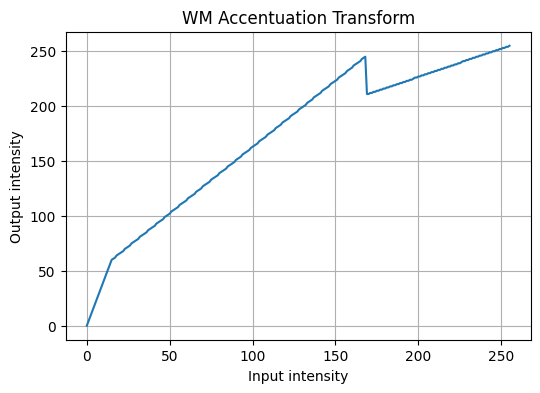

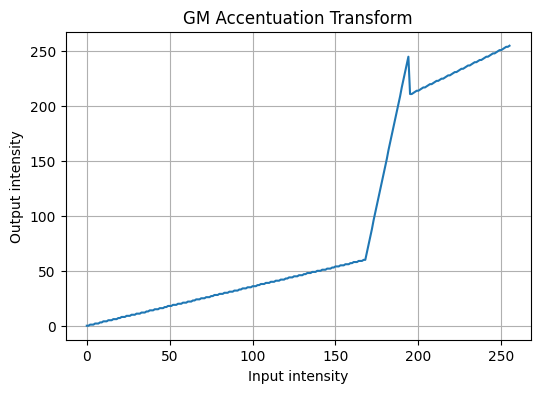

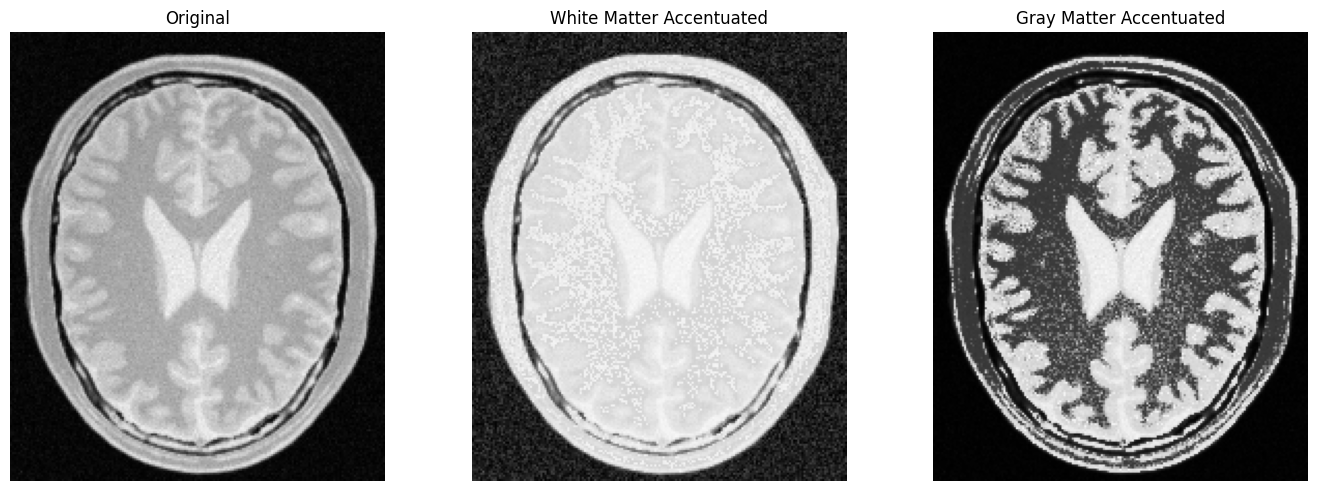

Saved files:
  WM: /content/drive/MyDrive/Computer Vision/Assignment 1/brain_proton_density_slice_wm.png
  GM: /content/drive/MyDrive/Computer Vision/Assignment 1/brain_proton_density_slice_gm.png


In [6]:
#==== Question 2 ====#

import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# ----------- CONFIG -----------
IN_PATH = "/content/drive/MyDrive/Computer Vision/Assignment 1/brain_proton_density_slice.png"

# Optional: manually override breakpoints if you already know good ones.
# Set to None to auto-pick from percentiles.
MANUAL_WM_RANGE = None   # e.g., (50, 175)
MANUAL_GM_RANGE = None   # e.g., (175, 215)

# How aggressively to expand the target band and compress the rest.
PRE_TOP      = 60    # max output for below-a range
FOCUS_TOP    = 245   # max output for a..b target band
POST_BOTTOM  = 210   # min output for above-b range
BACKGROUND_CUTOFF = 5  # ignore intensities <= this when estimating percentiles
# ------------------------------

# --- helpers ---
def load_gray(path):
    return np.array(Image.open(path).convert("L"), dtype=np.uint8)

def save_gray(arr, path):
    Image.fromarray(arr, mode="L").save(path)

def build_focus_lut(a, b, pre_top=60, focus_top=245, post_bottom=210):
    a = int(max(0, min(254, a)))
    b = int(max(a+1, min(255, b)))
    lut = np.zeros(256, dtype=np.uint8)

    # [0, a] -> [0, pre_top]  (compress shadows)
    for x in range(0, a+1):
        y = (pre_top / max(a, 1)) * x
        lut[x] = np.clip(int(round(y)), 0, 255)

    # [a, b] -> [pre_top, focus_top]  (expand target band)
    for x in range(a+1, b+1):
        y = pre_top + (focus_top - pre_top) * (x - a) / (b - a)
        lut[x] = np.clip(int(round(y)), 0, 255)

    # [b, 255] -> [post_bottom, 255]  (compress highlights)
    for x in range(b+1, 256):
        y = post_bottom + (255 - post_bottom) * (x - b) / (255 - b)
        lut[x] = np.clip(int(round(y)), 0, 255)

    return lut

def apply_lut(img_u8, lut):
    return lut[img_u8]

def suggest_ranges(arr_u8, bg_cutoff=5):
    """Suggest (a,b) from robust percentiles of non-background pixels."""
    v = arr_u8.flatten()
    v = v[v > bg_cutoff]         # drop near-black background
    if v.size < 50:
        # fallback if image is too small or all background
        return (40, 175), (175, 215)

    p20 = int(np.percentile(v, 20))
    p50 = int(np.percentile(v, 50))
    p80 = int(np.percentile(v, 80))
    # WM darker -> lower-mid band; GM -> mid-high band
    wm_range = (p20, p50)
    gm_range = (p50, p80)
    return wm_range, gm_range

# --- pipeline ---
img = load_gray(IN_PATH)

# Auto-suggest ranges if not provided
wm_range_auto, gm_range_auto = suggest_ranges(img, bg_cutoff=BACKGROUND_CUTOFF)
wm_a, wm_b = MANUAL_WM_RANGE if MANUAL_WM_RANGE is not None else wm_range_auto
gm_a, gm_b = MANUAL_GM_RANGE if MANUAL_GM_RANGE is not None else gm_range_auto

print(f"Input image: {IN_PATH}")
print(f"Suggested WM range (a,b): {wm_a}, {wm_b}")
print(f"Suggested GM range (a,b): {gm_a}, {gm_b}")

# Build LUTs
lut_wm = build_focus_lut(wm_a, wm_b, PRE_TOP, FOCUS_TOP, POST_BOTTOM)
lut_gm = build_focus_lut(gm_a, gm_b, PRE_TOP, FOCUS_TOP, POST_BOTTOM)

# Apply
out_wm = apply_lut(img, lut_wm)
out_gm = apply_lut(img, lut_gm)

# Save results
root, ext = os.path.splitext(IN_PATH)
wm_path = root + "_wm.png"
gm_path = root + "_gm.png"
save_gray(out_wm, wm_path)
save_gray(out_gm, gm_path)

# --- Plots: two separate figures for the transform curves ---
x = np.arange(256)

plt.figure(figsize=(6,4))
plt.plot(x, lut_wm)
plt.title("WM Accentuation Transform")
plt.xlabel("Input intensity"); plt.ylabel("Output intensity")
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(x, lut_gm)
plt.title("GM Accentuation Transform")
plt.xlabel("Input intensity"); plt.ylabel("Output intensity")
plt.grid(True)
plt.show()

# --- Visualize images (side-by-side for quick inspection) ---
plt.figure(figsize=(14,5))
plt.subplot(1,3,1); plt.imshow(img, cmap="gray", vmin=0, vmax=255); plt.title("Original"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(out_wm, cmap="gray", vmin=0, vmax=255); plt.title("White Matter Accentuated"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(out_gm, cmap="gray", vmin=0, vmax=255); plt.title("Gray Matter Accentuated"); plt.axis("off")
plt.tight_layout()
plt.show()

print("Saved files:")
print("  WM:", wm_path)
print("  GM:", gm_path)


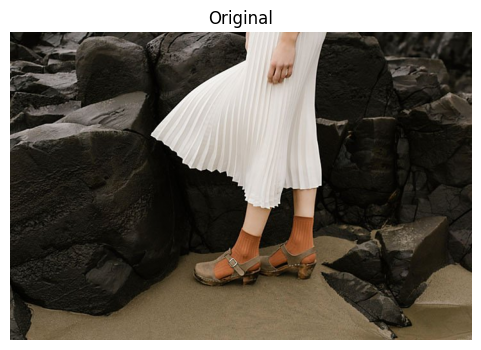

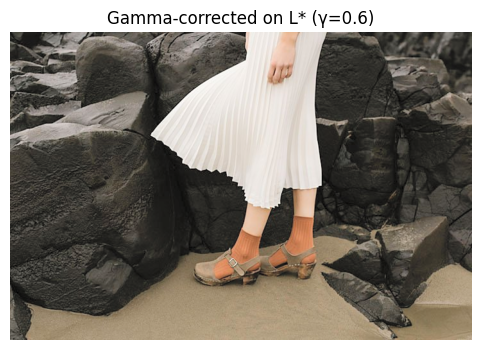

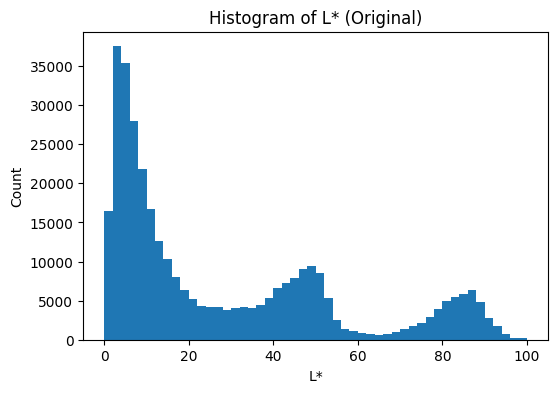

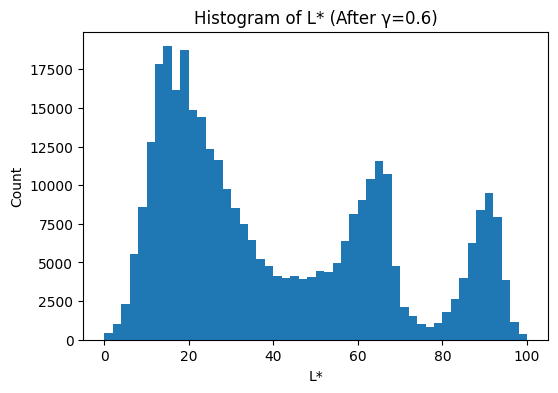

Saved corrected image to: /content/drive/MyDrive/Computer Vision/Assignment 1/highlights_and_shadows_gamma_0p6.png


In [3]:
import os, numpy as np, matplotlib.pyplot as plt
from PIL import Image
from skimage import color, img_as_float

# ---- Input path (change if needed) ----
IN_PATH = "/content/drive/MyDrive/Computer Vision/Assignment 1/highlights_and_shadows.jpg"

# ---- Gamma value (state this in your report) ----
gamma = 0.6   # <--- gamma < 1 brightens midtones; gamma > 1 darkens

# ---- Load image (RGB) ----
rgb = np.array(Image.open(IN_PATH).convert("RGB"))
rgb_f = img_as_float(rgb)       # [0,1]

# ---- RGB -> Lab (L in [0,100]) ----
lab = color.rgb2lab(rgb_f)
L, A, B = lab[...,0], lab[...,1], lab[...,2]

# ---- Gamma on L* ----
Ln = np.clip(L / 100.0, 0.0, 1.0)
L_corr = 100.0 * (Ln ** gamma)

# ---- Recombine + Lab -> RGB ----
lab_corr = np.stack([L_corr, A, B], axis=-1)
rgb_corr = np.clip(color.lab2rgb(lab_corr), 0.0, 1.0)

# ---- Save result ----
root, ext = os.path.splitext(IN_PATH)
OUT_PATH = f"{root}_gamma_{str(gamma).replace('.','p')}.png"
Image.fromarray((rgb_corr*255).astype(np.uint8)).save(OUT_PATH)

# ---- Show images ----
plt.figure(figsize=(6,4))
plt.imshow(rgb_f); plt.title("Original"); plt.axis("off"); plt.show()

plt.figure(figsize=(6,4))
plt.imshow(rgb_corr); plt.title(f"Gamma-corrected on L* (γ={gamma})"); plt.axis("off"); plt.show()

# ---- Histograms of L* (before/after) ----
plt.figure(figsize=(6,4))
plt.hist(L.ravel(), bins=50); plt.title("Histogram of L* (Original)")
plt.xlabel("L*"); plt.ylabel("Count"); plt.show()

plt.figure(figsize=(6,4))
plt.hist(L_corr.ravel(), bins=50); plt.title(f"Histogram of L* (After γ={gamma})")
plt.xlabel("L*"); plt.ylabel("Count"); plt.show()

print("Saved corrected image to:", OUT_PATH)